In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [2]:
# load data
df = pd.read_csv("../data/cleaned/cleaned_credit_card_approval_1.csv")
df.head()

,applicant_gender,total_income,income_type,education_type,family_status,job_title,applicant_age,years_of_working,total_bad_debt,total_good_debt,status
0,Male,180000,Working,Secondary / Secondary Special,Married,Managers,45,7,0,28,1
1,Unknown,112500,Unknown,Unknown,Unknown,Unknown,40,7,0,18,1
2,Female,270000,State Servant,Higher Education,Married,Unknown,40,7,0,27,1
3,Female,135000,Unknown,Unknown,Unknown,Core Staff,40,6,9,40,1
4,Unknown,94500,State Servant,Higher Education,Unknown,Unknown,51,6,0,46,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10454 entries, 0 to 10453
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   applicant_gender  10454 non-null  object
 1   total_income      10454 non-null  int64 
 2   income_type       10454 non-null  object
 3   education_type    10454 non-null  object
 4   family_status     10454 non-null  object
 5   job_title         10454 non-null  object
 6   applicant_age     10454 non-null  int64 
 7   years_of_working  10454 non-null  int64 
 8   total_bad_debt    10454 non-null  int64 
 9   total_good_debt   10454 non-null  int64 
 10  status            10454 non-null  int64 
dtypes: int64(6), object(5)
memory usage: 898.5+ KB


In [4]:
# data overview
df.describe()

,total_income,applicant_age,years_of_working,total_bad_debt,total_good_debt,status
count,10454.000000,10454.000000,10454.000000,10454.000000,10454.000000,10454.000000
mean,193344.411230,40.551368,7.428831,0.212359,20.015975,0.996269
std,94621.767306,7.436494,5.043621,1.228063,11.575177,0.060968
min,27000.000000,22.000000,1.000000,0.000000,1.000000,0.000000
25%,135000.000000,38.000000,5.000000,0.000000,15.000000,1.000000
50%,180000.000000,40.000000,7.000000,0.000000,18.000000,1.000000
75%,225000.000000,43.000000,7.000000,0.000000,21.000000,1.000000
max,787500.000000,68.000000,44.000000,40.000000,61.000000,1.000000


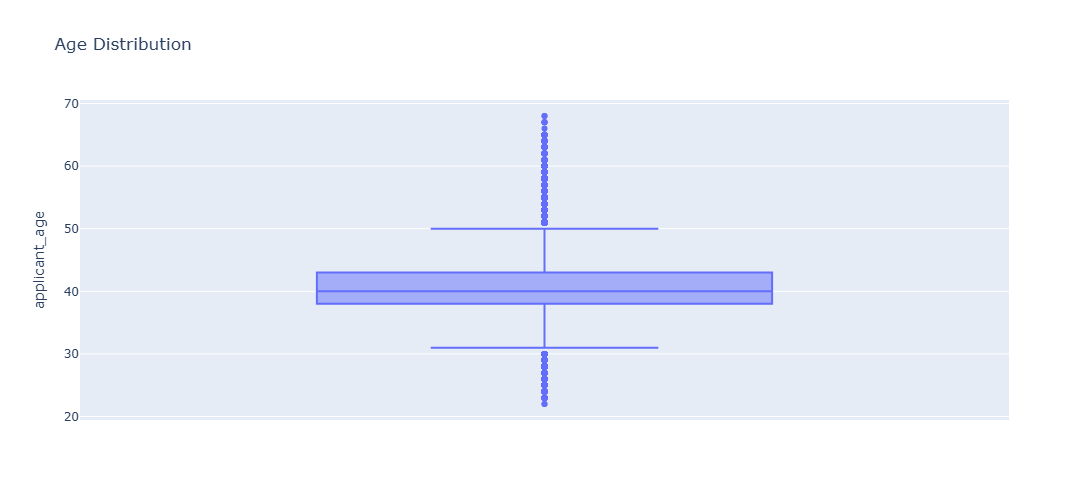

In [5]:
# Univariate Analysis: Distribution of age
px.box(
    df,
    y="applicant_age",
    width=500,
    height=500,
    title="Age Distribution"
)

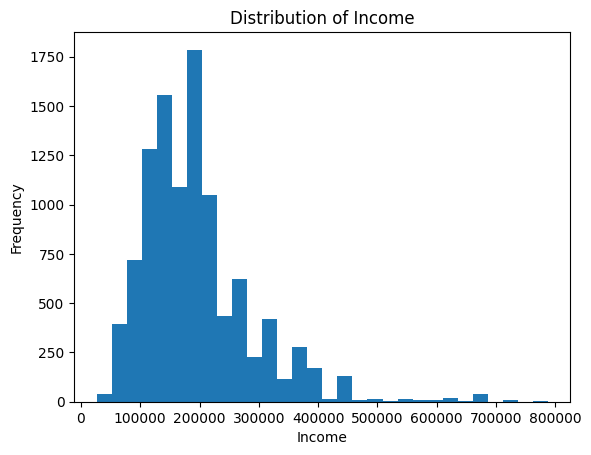

In [6]:
 # Univariate Analysis: Distribution of total income
plt.hist(df["total_income"], bins=30)
plt.title("Distribution of Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

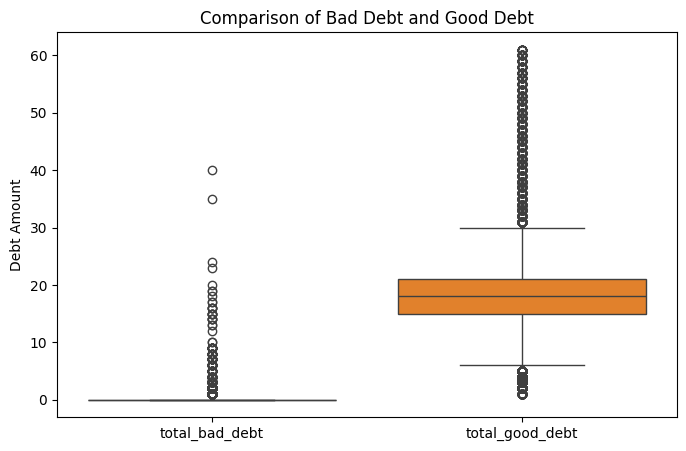

In [7]:
 # Univariate Analysis: Distribution of total debt
plt.figure(figsize=(8,5))

sns.boxplot(data=df[["total_bad_debt", "total_good_debt"]])

plt.title("Comparison of Bad Debt and Good Debt")
plt.ylabel("Debt Amount")
plt.show()

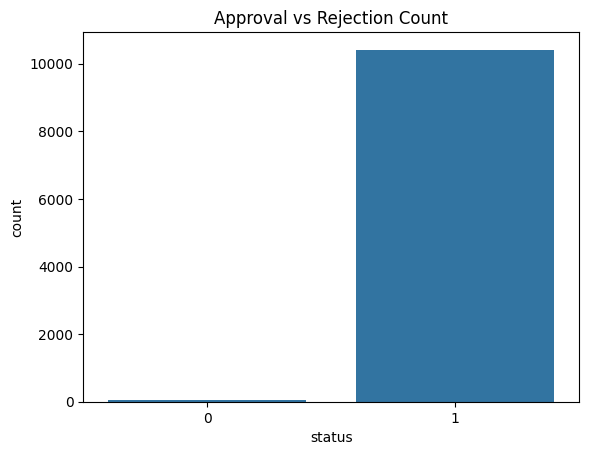

status
1    99.626937
0     0.373063
Name: proportion, dtype: float64


In [8]:
# Univariate Analysis: approval rate
sns.countplot(x="status", data=df)
plt.title("Approval vs Rejection Count")
plt.show()

print(df["status"].value_counts(normalize=True) * 100)

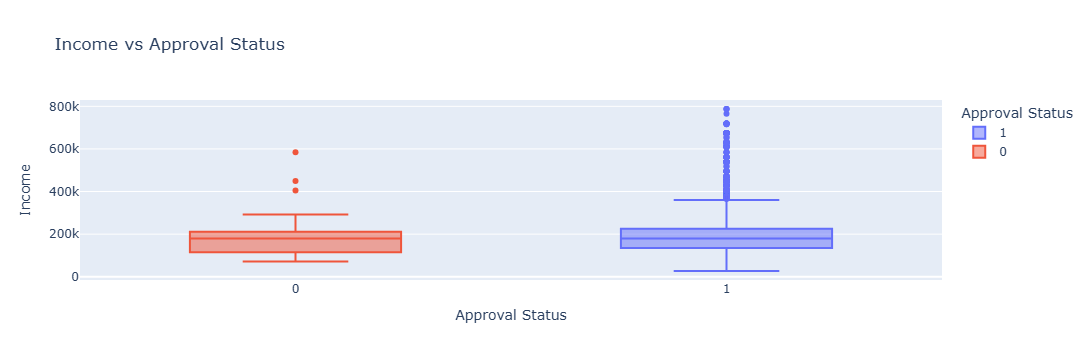

In [9]:
# BIVARIATE ANALYSIS: Income vs Approval
fig = px.box(
    df,
    x="status",
    y="total_income",
    color="status",
    title="Income vs Approval Status",
    labels={
        "status": "Approval Status",
        "total_income": "Income"
    }
)
fig.show()

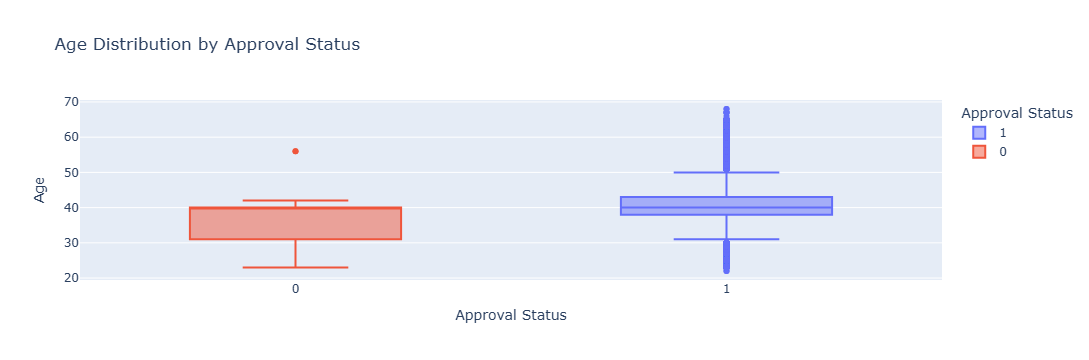

In [10]:
# BIVARIATE ANALYSIS: Age vs Approval
fig = px.box(
    df,
    x="status",
    y="applicant_age",
    color="status",
    title="Age Distribution by Approval Status",
    labels={
        "status": "Approval Status",
        "applicant_age": "Age"
    }
)

# fig.update_layout(
#     template="plotly_white",
#     title_x=0.5
# )

fig.show()

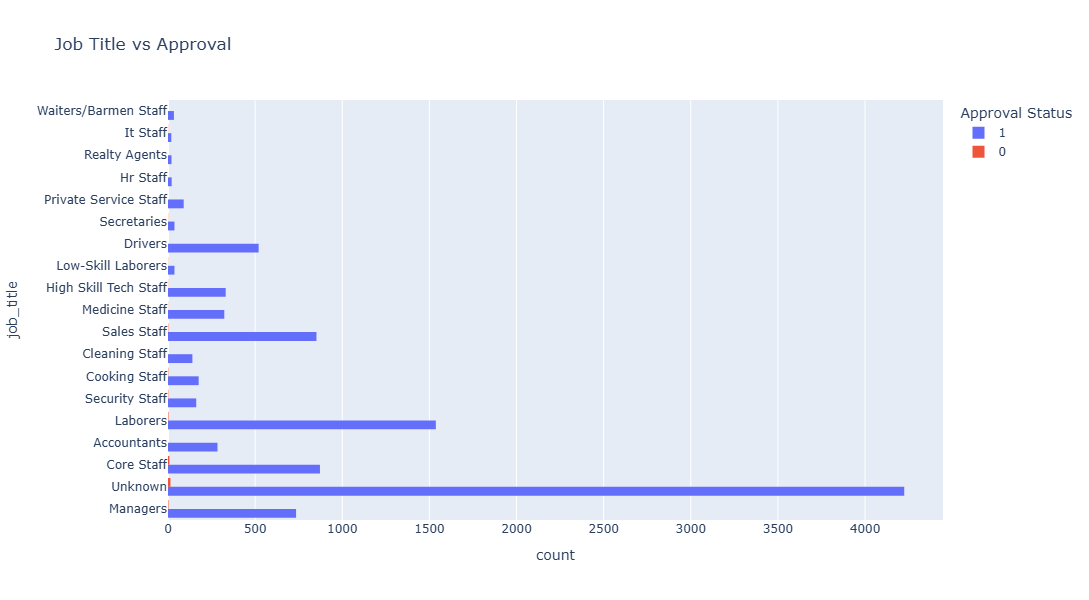

In [11]:
# BIVARIATE ANALYSIS: job title vs Approval
fig = px.histogram(
    df,
    y="job_title",
    color="status",
    barmode="group",
    title="Job Title vs Approval",
    labels={
        "Job_title": "Job Title",
        "status": "Approval Status"
    },
    height=600,
    width=800,
    orientation="h"
)
fig.show()

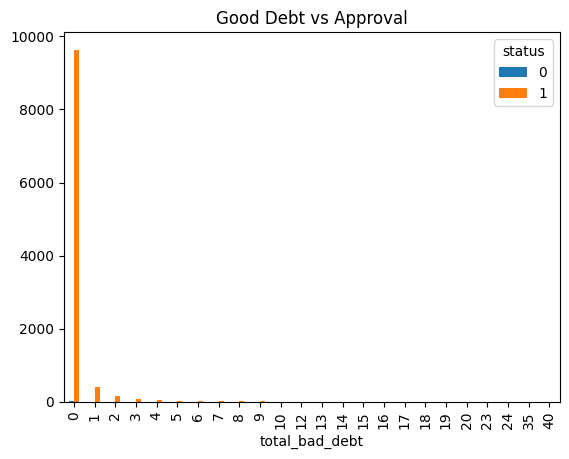

In [12]:
# BIVARIATE ANALYSIS: good debt vs Approval
pd.crosstab(df["total_bad_debt"], df["status"]).plot(kind="bar")
plt.title("Good Debt vs Approval")
plt.show()

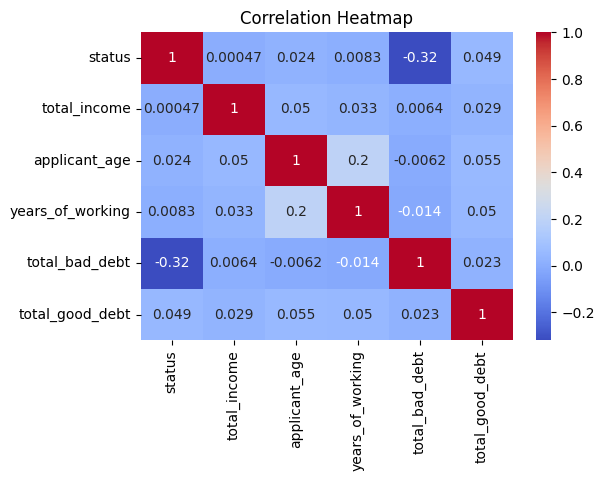

In [13]:
# MULTIVARIATE ANALYSIS: heat map correlation
plt.figure(figsize=(6,4))
corr = df[["status", "total_income", "applicant_age", "years_of_working", "total_bad_debt", "total_good_debt"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


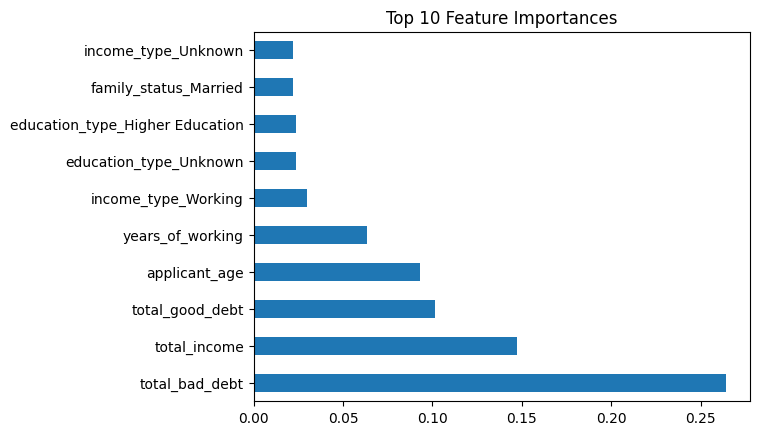

In [14]:
# MULTIVARIATE ANALYSIS: inital feature importance
X = df.drop("status", axis=1)
y = df["status"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind="barh")
plt.title("Top 10 Feature Importances")
plt.show()